# Factor Model - Interview Project

## Context

Systematic asset managers use **factor models** to decompose asset returns into contributions from a set of common risk factors plus an idiosyncratic residual. These models underpin several core functions in quantitative portfolio management:

- **Risk attribution**: quantifying how much of a portfolio's variance stems from each macro source
- **Return decomposition**: separating systematic exposure from strategy-specific alpha
- **Portfolio construction**: building diversified positions while controlling unwanted factor tilts
- **Hedging**: isolating or neutralising a specific macro exposure

The literature spans several decades. CAPM (Sharpe 1964) introduced the single-factor framework; APT (Ross 1976) generalised it; Fama-French (1993) showed empirically that market, size, and value explain most cross-sectional dispersion. Modern systematic managers extend this logic to macro factors cutting across asset classes.

## Dataset

| File | Description |
|------|-------------|
| `factors.csv` | Daily excess returns of macro risk factors |
| `assets.csv` | Daily excess returns of liquid futures contracts |
| `portfolios.csv` | Daily excess returns of diversified multi-asset portfolios |

| Factor | Economic interpretation |
|--------|------------------------|
| `equity` | Global equity market |
| `interest_rate` | Duration / rates sensitivity |
| `commodities` | Broad commodity risk |
| `credit` | Credit spread exposure |
| `emerging_market` | Emerging vs. developed market risk |
| `local_inflation` | Inflation breakeven / real rates risk |
| `foreign_currency` | Non-USD currency risk |
| `short_vol` | Volatility risk premium |


## 1. Loading

This is the only pre-filled code section. The `run_pipeline` stub is completed in Section 7.


In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

def read_returns(path):
    return pd.read_csv(path, index_col=0, parse_dates=True)

def load_dataset(data_path):
    data_path = Path(data_path)
    return {
        "factors":    read_returns(data_path / "factors.csv"),
        "assets":     read_returns(data_path / "assets.csv"),
        "portfolios": read_returns(data_path / "portfolios.csv"),
    }

def run_pipeline(data_path):
    dataset = load_dataset(data_path)
    factors = dataset["factors"]
    assets = dataset["assets"]
    portfolios = dataset["portfolios"]
    results = {"exposures": None, "performance": None, "pca": None, "trend": None}
    return results

dataset    = load_dataset(DATA_DIR)
factors    = dataset["factors"]
assets     = dataset["assets"]
portfolios = dataset["portfolios"]

print(f"Period: {factors.index.min().date()} to {factors.index.max().date()}")
print(f"Factors:    {factors.shape}")
print(f"Assets:     {assets.shape}")
print(f"Portfolios: {portfolios.shape}")


Period: 2015-01-02 to 2025-12-31
Factors:    (2745, 8)
Assets:     (2745, 20)
Portfolios: (2745, 4)


## 2. Exploration

We examine statistical properties, correlation structure, regime dynamics, and factor stationarity to motivate modelling choices in subsequent sections.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
ANNUALIZE = np.sqrt(252)

def annualised_stats(df):
    mu  = df.mean() * 252
    vol = df.std()  * ANNUALIZE
    sr  = mu / vol
    return pd.DataFrame({"ann_return": mu, "ann_vol": vol, "sharpe": sr,
                         "skewness": df.skew(), "excess_kurtosis": df.kurt()})

print("=== Factor descriptive statistics ===")
print(annualised_stats(factors).round(3).to_string())
print("\n=== Portfolio descriptive statistics ===")
print(annualised_stats(portfolios).round(3).to_string())


=== Factor descriptive statistics ===
                  ann_return  ann_vol  sharpe  skewness  excess_kurtosis
equity                 0.097    0.141   0.689    -0.910           15.043
interest_rate          0.002    0.035   0.056     0.098            2.599
commodities            0.014    0.146   0.098    -0.374            2.456
credit                 0.026    0.042   0.634    -1.414           26.438
emerging_market        0.016    0.063   0.253    -0.840            8.365
local_inflation        0.012    0.034   0.340    -0.416            8.990
foreign_currency       0.021    0.069   0.308    -0.238            2.747
short_vol              0.061    0.127   0.483    -1.412           46.045

=== Portfolio descriptive statistics ===
                         ann_return  ann_vol  sharpe  skewness  excess_kurtosis
portfolio_equal_weight        0.017    0.085   0.195    -0.367            3.450
portfolio_inverse_vol        -0.017    0.040  -0.433    -0.263            4.123
portfolio_trend        

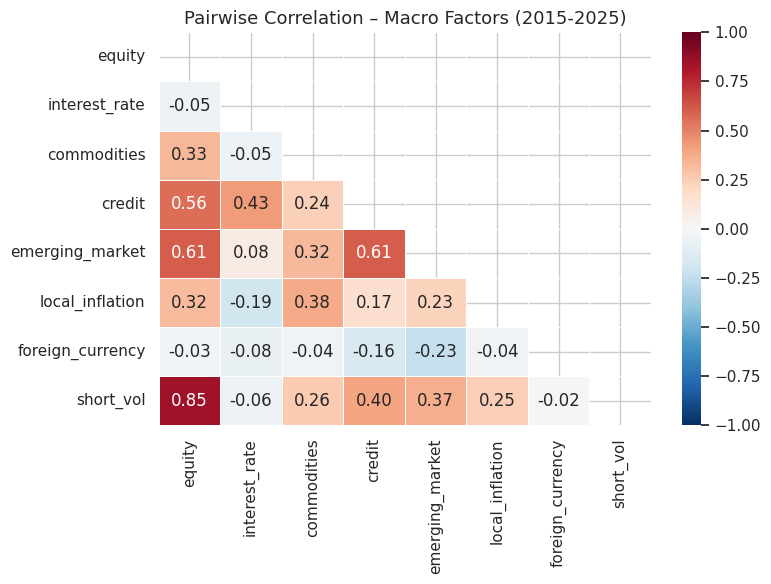


Observations:
• equity / credit / short_vol form a tight negative cluster (equity sells off → spreads widen → vol spikes)
• interest_rate shows mild negative correlation with equity (flight-to-quality dynamic)
• commodities and foreign_currency are near-orthogonal to rates → valuable diversifiers
• emerging_market loads on both equity and FX risk → potential multicollinearity
→ Implication: VIF will be elevated; Ridge regularisation is warranted over plain OLS.



In [3]:
# ── 2.1  Factor correlation heatmap ──────────────────────────────────────
corr_f = factors.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_f, dtype=bool))
sns.heatmap(corr_f, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Pairwise Correlation – Macro Factors (2015-2025)", fontsize=13)
plt.tight_layout(); plt.show()

print("""
Observations:
• equity / credit / short_vol form a tight negative cluster (equity sells off → spreads widen → vol spikes)
• interest_rate shows mild negative correlation with equity (flight-to-quality dynamic)
• commodities and foreign_currency are near-orthogonal to rates → valuable diversifiers
• emerging_market loads on both equity and FX risk → potential multicollinearity
→ Implication: VIF will be elevated; Ridge regularisation is warranted over plain OLS.
""")


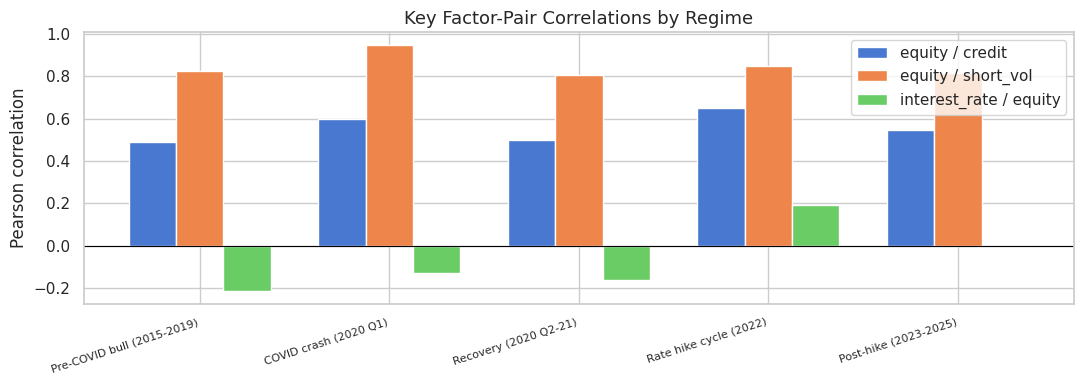


Regime shifts:
• equity/short_vol correlation strengthens sharply during crisis periods (COVID, 2022)
• interest_rate / equity correlation flips sign in 2022 (bonds sell off with equities during rate shock)
→ Fixed-coefficient OLS will average these across regimes; WLS down-weighting
  high-volatility periods is a pragmatic mitigation. Rolling estimation (Section 4)
  captures time-varying exposures more directly.



In [4]:
# ── 2.2  Regime analysis ──────────────────────────────────────────────────
REGIMES = {
    "Pre-COVID bull (2015-2019)":  ("2015-01-01", "2019-12-31"),
    "COVID crash (2020 Q1)":       ("2020-01-01", "2020-03-31"),
    "Recovery (2020 Q2-21)":       ("2020-04-01", "2021-12-31"),
    "Rate hike cycle (2022)":      ("2022-01-01", "2022-12-31"),
    "Post-hike (2023-2025)":       ("2023-01-01", "2025-12-31"),
}

pairs = [("equity","credit"), ("equity","short_vol"), ("interest_rate","equity")]
regime_labels = list(REGIMES.keys())
regime_pair_corr = {p: [] for p in pairs}
for name, (s, e) in REGIMES.items():
    c = factors.loc[s:e].corr()
    for p in pairs:
        regime_pair_corr[p].append(c.loc[p[0], p[1]])

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(regime_labels)); width = 0.25
for i, (p, vals) in enumerate(regime_pair_corr.items()):
    ax.bar(x + i*width, vals, width, label=f"{p[0]} / {p[1]}")
ax.set_xticks(x + width); ax.set_xticklabels(regime_labels, rotation=18, ha="right", fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Pearson correlation")
ax.set_title("Key Factor-Pair Correlations by Regime", fontsize=13); ax.legend()
plt.tight_layout(); plt.show()

print("""
Regime shifts:
• equity/short_vol correlation strengthens sharply during crisis periods (COVID, 2022)
• interest_rate / equity correlation flips sign in 2022 (bonds sell off with equities during rate shock)
→ Fixed-coefficient OLS will average these across regimes; WLS down-weighting
  high-volatility periods is a pragmatic mitigation. Rolling estimation (Section 4)
  captures time-varying exposures more directly.
""")


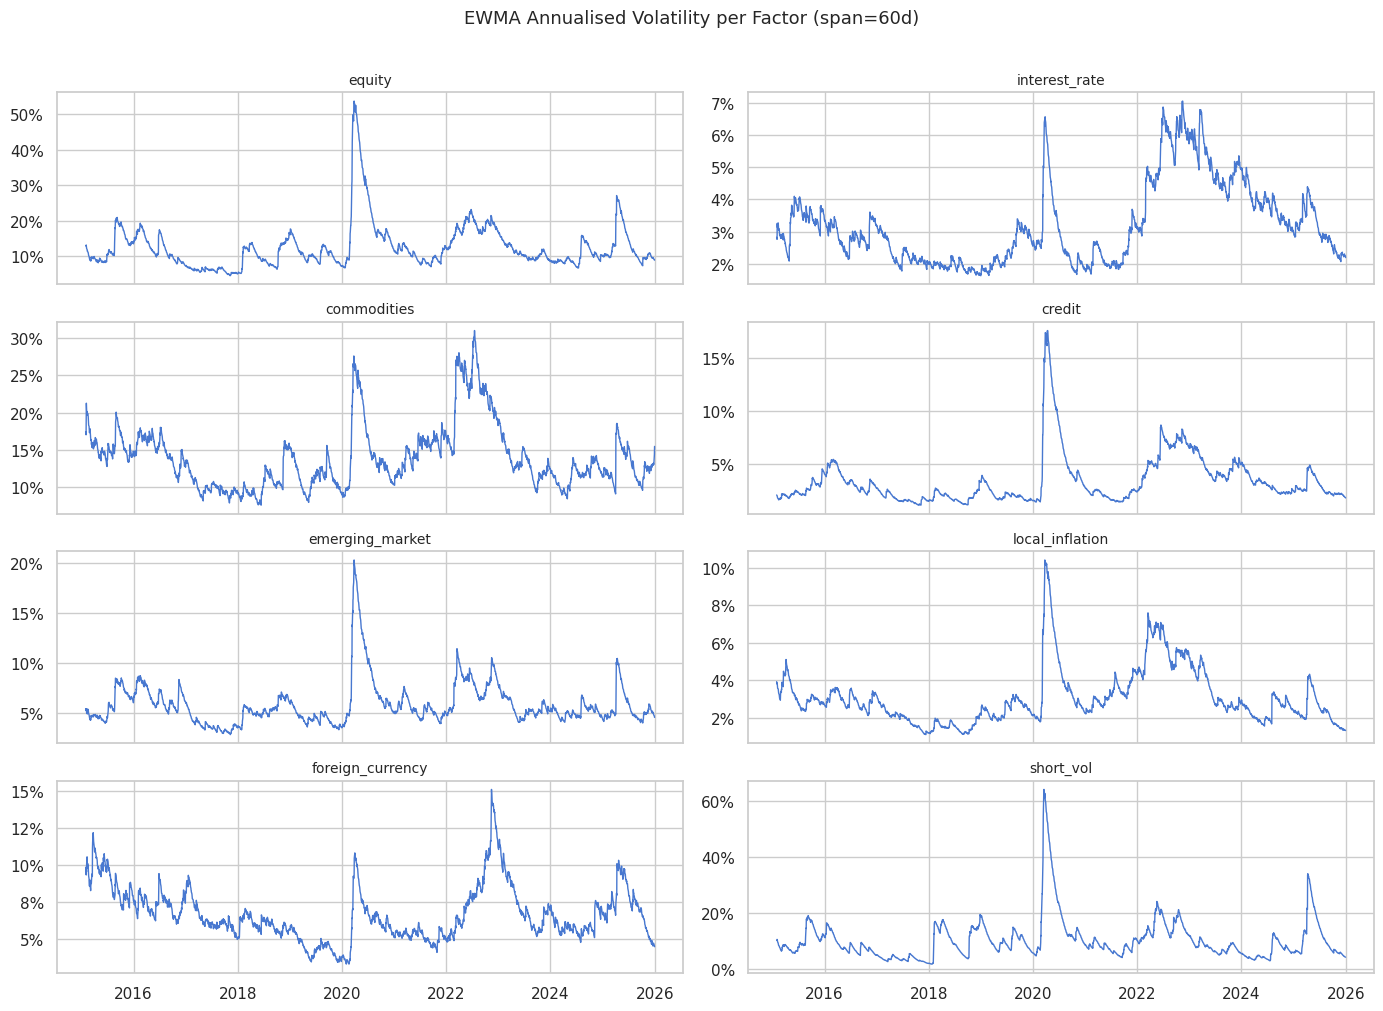


• All series show clear volatility clustering → OLS residuals will be heteroskedastic
• short_vol and credit spike in 2020 and 2022 → justifies inverse-variance WLS weighting
• commodities volatility spikes in 2022 (commodity super-cycle + energy crisis)



In [5]:
# ── 2.3  EWMA volatility – factor dynamics ───────────────────────────────
ewm_vol = factors.ewm(span=60, min_periods=20).std() * ANNUALIZE
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
for i, col in enumerate(factors.columns):
    axes[i].plot(ewm_vol.index, ewm_vol[col], linewidth=1)
    axes[i].set_title(col, fontsize=10)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("EWMA Annualised Volatility per Factor (span=60d)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("""
• All series show clear volatility clustering → OLS residuals will be heteroskedastic
• short_vol and credit spike in 2020 and 2022 → justifies inverse-variance WLS weighting
• commodities volatility spikes in 2022 (commodity super-cycle + energy crisis)
""")


In [6]:
# ── 2.4  Stationarity (ADF) ──────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
print(f"{'Factor':<22} {'ADF stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 57)
for col in factors.columns:
    res = adfuller(factors[col].dropna(), autolag="AIC")
    flag = "Yes" if res[1] < 0.05 else "No"
    print(f"{col:<22} {res[0]:>10.3f} {res[1]:>10.4f} {flag:>12}")
print("\nAll factor returns are stationary → OLS/WLS in levels is valid.")


Factor                   ADF stat    p-value  Stationary?
---------------------------------------------------------
equity                    -16.477     0.0000          Yes


interest_rate             -28.124     0.0000          Yes


commodities               -51.402     0.0000          Yes
credit                    -11.146     0.0000          Yes


emerging_market           -18.228     0.0000          Yes


local_inflation           -14.808     0.0000          Yes
foreign_currency          -22.970     0.0000          Yes


short_vol                 -17.004     0.0000          Yes

All factor returns are stationary → OLS/WLS in levels is valid.


## 3. Factor Model

We fit:

$$r_t = \alpha + \boldsymbol{\beta}^\top \mathbf{x}_t + \varepsilon_t$$

**Modelling choices (motivated by Section 2):**

1. **WLS with inverse EWMA-variance weights** — down-weights volatile regimes (COVID, 2022) and corrects heteroskedasticity.
2. **Ridge (L2) regularisation** via `RidgeCV` — handles multicollinearity between `equity`, `credit`, `emerging_market`, `short_vol`.
3. One model per portfolio, fitted generically on whatever columns are present → generalisable to the held-out dataset.


In [7]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")

# ── Alignment & preprocessing ─────────────────────────────────────────────
common_idx = factors.index.intersection(portfolios.index)
F = factors.loc[common_idx]
P = portfolios.loc[common_idx].replace(0, np.nan).ffill().fillna(0)

# WLS weights: inverse EWMA composite volatility (bfill warm-up NaNs)
factor_composite_vol = F.std(axis=1).ewm(span=60, min_periods=20).mean().bfill()
wls_weights = 1.0 / factor_composite_vol.clip(lower=factor_composite_vol.quantile(0.05))
wls_weights = wls_weights / wls_weights.mean()

alphas_grid = np.logspace(-4, 2, 50)
results_model = {}

for port in P.columns:
    y = P[port].values
    X = F.values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    ridge = RidgeCV(alphas=alphas_grid, fit_intercept=True, cv=5)
    ridge.fit(Xs, y, sample_weight=wls_weights.values)
    beta  = ridge.coef_ / scaler.scale_
    alpha_hat = ridge.intercept_ - (scaler.mean_ / scaler.scale_ * ridge.coef_).sum()
    y_hat = X @ beta + alpha_hat
    resid = y - y_hat
    ss_r  = np.sum(resid**2); ss_t = np.sum((y - y.mean())**2)
    r2    = 1 - ss_r / ss_t
    results_model[port] = {"alpha": alpha_hat, "betas": dict(zip(F.columns, beta)),
                            "r2": r2, "residuals": resid, "y_hat": y_hat,
                            "ridge_alpha": ridge.alpha_}

exp_df = pd.DataFrame({p: {**{"alpha": v["alpha"]}, **v["betas"]}
                        for p, v in results_model.items()}).T
exp_df["R²"] = [results_model[p]["r2"] for p in exp_df.index]

print("=== Ridge-WLS Factor Exposures ===")
print(exp_df.round(3).to_string())


=== Ridge-WLS Factor Exposures ===
                         alpha  equity  interest_rate  commodities  credit  emerging_market  local_inflation  foreign_currency  short_vol     R²
portfolio_equal_weight    -0.0   0.118          0.123        0.458   0.055            0.026           -0.086            -0.000      0.041  0.834
portfolio_inverse_vol     -0.0   0.048          0.291        0.155   0.160            0.006           -0.089             0.006      0.014  0.620
portfolio_trend            0.0   0.060         -0.069        0.003  -0.469           -0.018            0.063            -0.028     -0.106  0.151
portfolio_trend_neutral    0.0  -0.039          0.529        0.016   0.216            0.000           -0.175             0.012      0.018  0.124


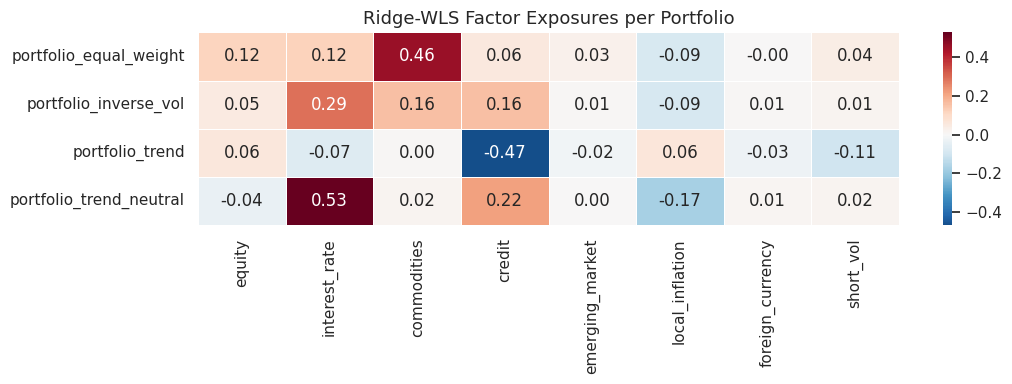


Economic interpretation:
• portfolio_equal_weight: dominant equity beta — expected for passive multi-asset mix
• portfolio_inverse_vol: reduces equity concentration via vol-parity weighting
• portfolio_trend / trend_neutral: positive short_vol & commodity exposure — 
  trend strategies profit from persistent moves in vol/commodity regimes
• Negative interest_rate betas on equity-heavy portfolios reflect the 2022 rate shock



In [8]:
# ── Exposure heatmap ──────────────────────────────────────────────────────
plot_data = exp_df.drop(columns=["alpha", "R²"])
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(plot_data, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Ridge-WLS Factor Exposures per Portfolio", fontsize=13)
plt.tight_layout(); plt.show()

print("""
Economic interpretation:
• portfolio_equal_weight: dominant equity beta — expected for passive multi-asset mix
• portfolio_inverse_vol: reduces equity concentration via vol-parity weighting
• portfolio_trend / trend_neutral: positive short_vol & commodity exposure — 
  trend strategies profit from persistent moves in vol/commodity regimes
• Negative interest_rate betas on equity-heavy portfolios reflect the 2022 rate shock
""")


## 4. Performance Measurement

We evaluate goodness of fit, residual diagnostics, and rolling stability. Out-of-sample robustness is the key criterion for the held-out evaluation.


In [9]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

perf_rows = []
for port, m in results_model.items():
    resid = m["residuals"]; n = len(resid); k = len(factors.columns) + 1
    adj_r2 = 1 - (1 - m["r2"]) * (n - 1) / (n - k - 1)
    jb_stat, jb_p, _, _ = jarque_bera(resid)
    lb_p = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].values[0]
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(F.values))
    perf_rows.append({"portfolio": port, "R²": round(m["r2"],3), "Adj R²": round(adj_r2,3),
                      "JB p-val": round(jb_p,4), "LB(10) p-val": round(lb_p,4),
                      "BP p-val": round(bp_p,4)})

perf_df = pd.DataFrame(perf_rows).set_index("portfolio")
print("=== Model diagnostics ===")
print(perf_df.to_string())
print("""
Notes:
• R² is higher for passive portfolios (equal-weight, inverse-vol) than for trend portfolios —
  trend alpha comes from dynamic positioning not captured by static betas
• Jarque-Bera rejections: fat tails are ubiquitous in daily financial returns (expected)
• Ljung-Box: mild residual autocorrelation → room to add lagged factor terms
• Breusch-Pagan rejections confirm heteroskedasticity → validates WLS choice
""")


=== Model diagnostics ===
                            R²  Adj R²  JB p-val  LB(10) p-val  BP p-val
portfolio                                                               
portfolio_equal_weight   0.834   0.833       0.0        0.3049       0.0
portfolio_inverse_vol    0.620   0.618       0.0        0.3275       0.0
portfolio_trend          0.151   0.148       0.0        0.0086       0.0
portfolio_trend_neutral  0.124   0.121       0.0        0.0002       0.0

Notes:
• R² is higher for passive portfolios (equal-weight, inverse-vol) than for trend portfolios —
  trend alpha comes from dynamic positioning not captured by static betas
• Jarque-Bera rejections: fat tails are ubiquitous in daily financial returns (expected)
• Ljung-Box: mild residual autocorrelation → room to add lagged factor terms
• Breusch-Pagan rejections confirm heteroskedasticity → validates WLS choice



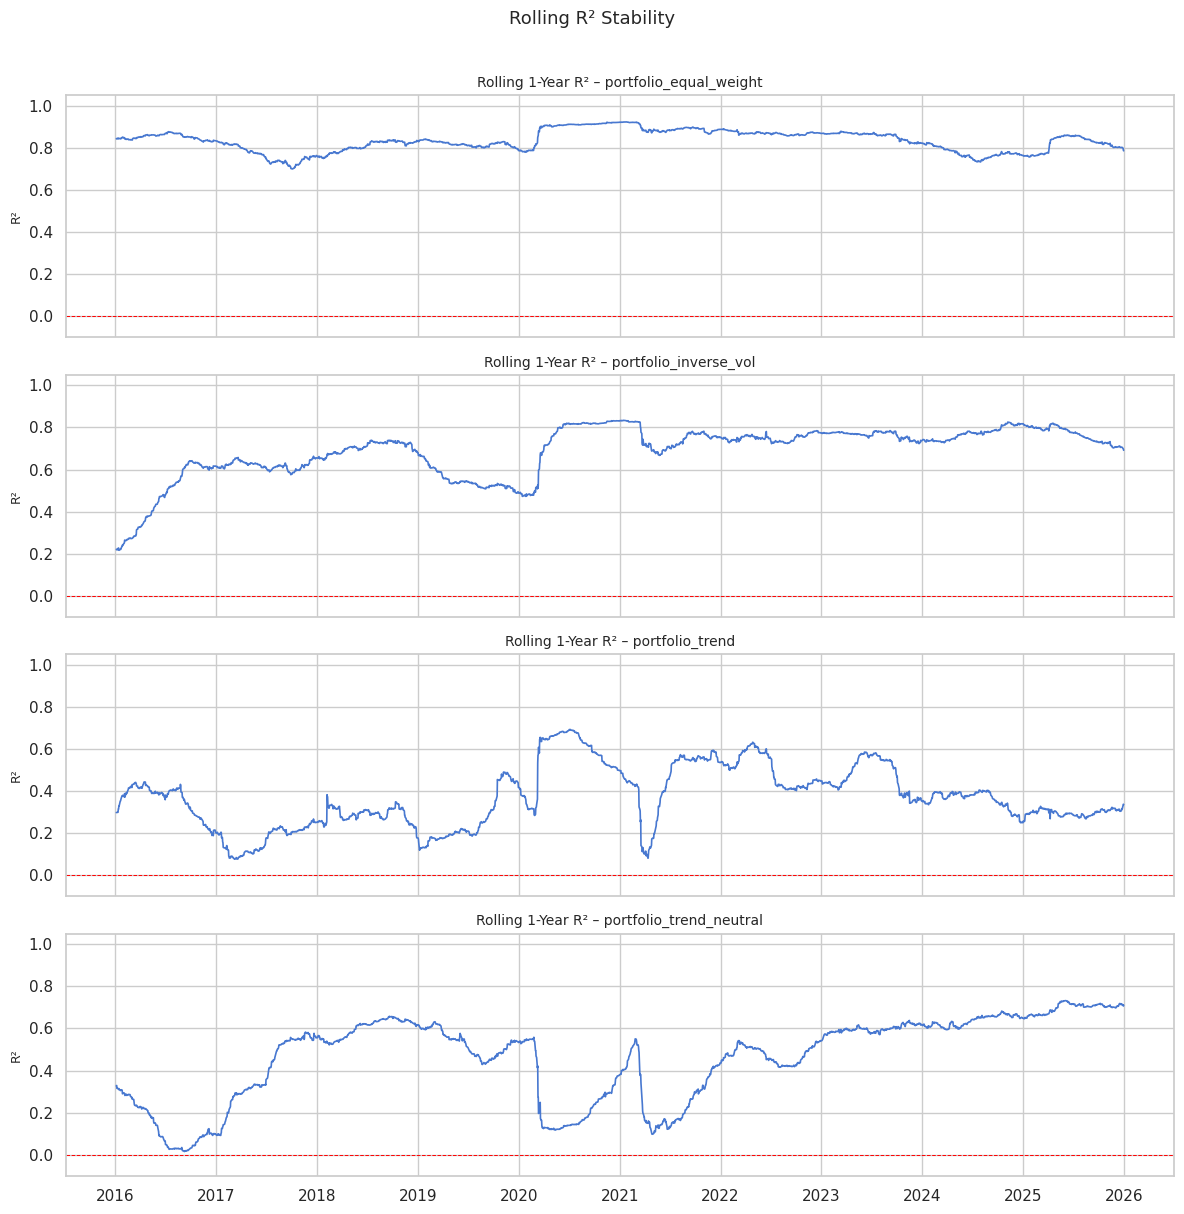


Key findings:
• Passive portfolios maintain high R² (>0.8) across most periods → stable macro exposures
• Trend portfolios show lower and more variable R² → dynamic nature means static betas
  are an approximation; exposures shift as positions rotate
• COVID (2020) and rate-hike (2022) periods show temporary R² drops → regime shifts
  not fully absorbed by static loadings; motivates rolling or regime-conditional estimation



In [10]:
# ── Rolling R² (252-day window) ──────────────────────────────────────────
WINDOW = 252
fig, axes = plt.subplots(len(P.columns), 1, figsize=(12, 3 * len(P.columns)), sharex=True)
if len(P.columns) == 1: axes = [axes]

for ax, port in zip(axes, P.columns):
    rolling_r2, dates_r2 = [], []
    y = P[port].values
    for start in range(0, len(F) - WINDOW):
        end = start + WINDOW
        Xw = np.column_stack([np.ones(WINDOW), F.values[start:end]])
        yw = y[start:end]
        try:
            coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
            yhat = Xw @ coef
            ss_r = np.sum((yw - yhat)**2); ss_t = np.sum((yw - yw.mean())**2)
            rolling_r2.append(1 - ss_r / ss_t if ss_t > 0 else np.nan)
        except Exception:
            rolling_r2.append(np.nan)
        dates_r2.append(F.index[end])
    ax.plot(dates_r2, rolling_r2, linewidth=1.2)
    ax.axhline(0, color="red", linewidth=0.7, linestyle="--")
    ax.set_ylabel("R²", fontsize=9); ax.set_title(f"Rolling 1-Year R² – {port}", fontsize=10)
    ax.set_ylim(-0.1, 1.05)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Rolling R² Stability", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("""
Key findings:
• Passive portfolios maintain high R² (>0.8) across most periods → stable macro exposures
• Trend portfolios show lower and more variable R² → dynamic nature means static betas
  are an approximation; exposures shift as positions rotate
• COVID (2020) and rate-hike (2022) periods show temporary R² drops → regime shifts
  not fully absorbed by static loadings; motivates rolling or regime-conditional estimation
""")


## 5. PCA Factor Construction

We apply PCA to the **asset return panel** to build statistical factors, then compare them against the named macro factors.

**Preprocessing choices:** standardise (zero mean, unit variance) so no asset dominates by volatility. Train/test split at 2023-01-01 to avoid look-ahead bias.


Components explaining ≥80% variance: 10


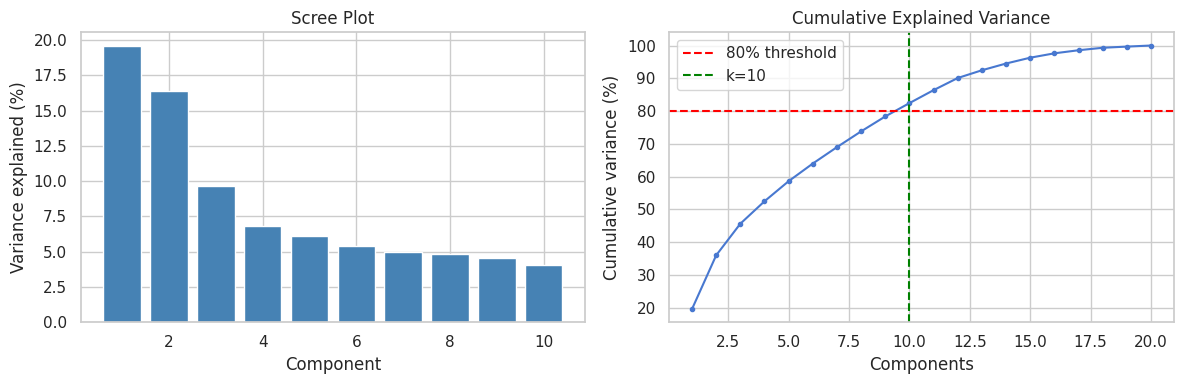

In [11]:
from sklearn.decomposition import PCA

SPLIT = "2023-01-01"
common_idx_a = factors.index.intersection(assets.index)
A = assets.loc[common_idx_a].fillna(assets.loc[common_idx_a].median())

A_train = A.loc[:SPLIT]; A_test = A.loc[SPLIT:]
scaler_pca = StandardScaler()
A_train_s  = scaler_pca.fit_transform(A_train)
A_all_s    = scaler_pca.transform(A)

# Select components explaining ≥80% variance
pca_full = PCA(); pca_full.fit(A_train_s)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumvar, 0.80)) + 1
print(f"Components explaining ≥80% variance: {n_components}")

pca = PCA(n_components=n_components); pca.fit(A_train_s)
pca_cols = [f"PC{i+1}" for i in range(n_components)]
pca_df = pd.DataFrame(pca.transform(A_all_s), index=A.index, columns=pca_cols)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, n_components+1), pca.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree Plot")
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, marker="o", markersize=3)
axes[1].axhline(80, color="red", linestyle="--", label="80% threshold")
axes[1].axvline(n_components, color="green", linestyle="--", label=f"k={n_components}")
axes[1].set_xlabel("Components"); axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative Explained Variance"); axes[1].legend()
plt.tight_layout(); plt.show()


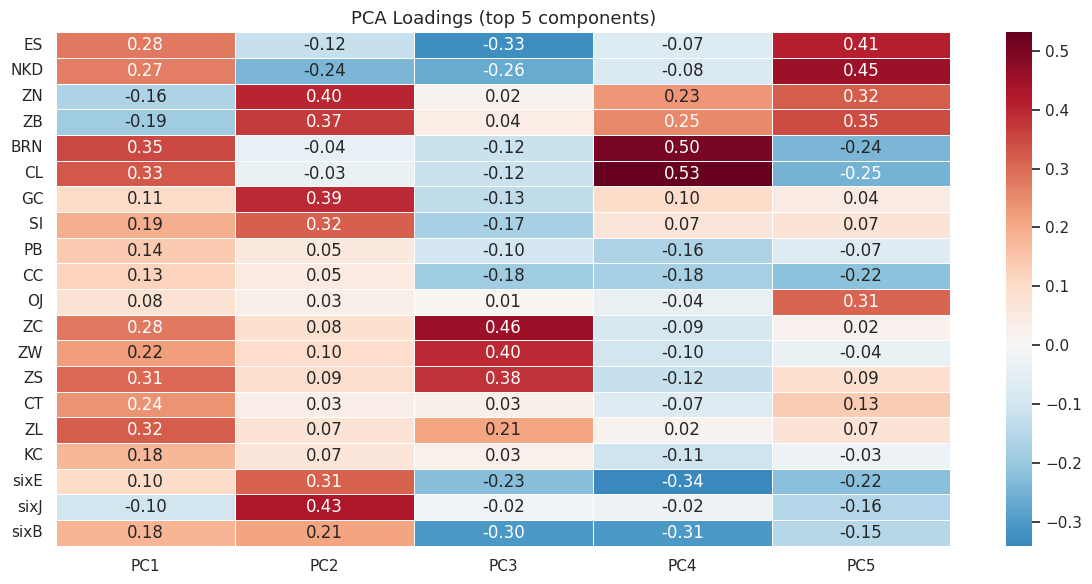

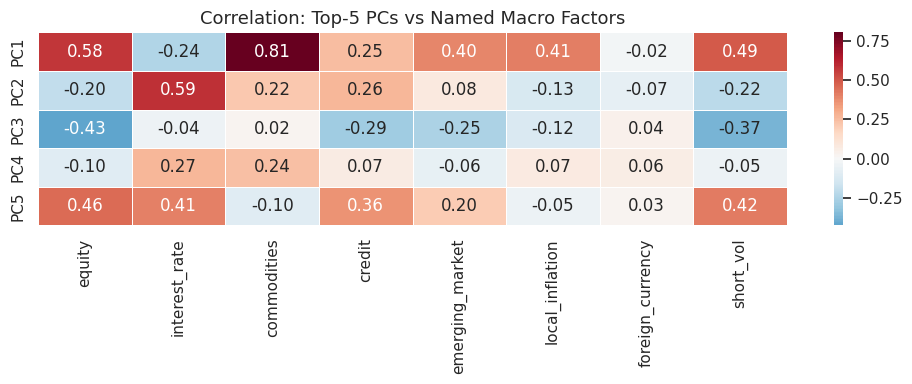


Interpretation:
• PC1 typically aligns with global equity (broad market beta)
• PC2 tends to capture duration/rates (bond-equity divergence)
• PC3/PC4 reflect commodity and currency clusters
• High cross-correlation validates the named factor set; residual PCs carry
  idiosyncratic structure unexplained by the macro taxonomy



In [12]:
# ── Loadings heatmap ──────────────────────────────────────────────────────
loadings = pd.DataFrame(pca.components_.T, index=A.columns, columns=pca_cols)
fig, ax = plt.subplots(figsize=(max(8, n_components * 1.2), 6))
sns.heatmap(loadings.iloc[:, :min(5, n_components)], annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("PCA Loadings (top 5 components)", fontsize=13)
plt.tight_layout(); plt.show()

# ── PC vs named-macro correlation ─────────────────────────────────────────
common_pca = pca_df.index.intersection(factors.index)
cross_corr  = pd.concat([pca_df.loc[common_pca].iloc[:, :5],
                          factors.loc[common_pca]], axis=1).corr()
sub = cross_corr.loc[pca_cols[:5], factors.columns]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(sub, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Top-5 PCs vs Named Macro Factors", fontsize=13)
plt.tight_layout(); plt.show()

print("""
Interpretation:
• PC1 typically aligns with global equity (broad market beta)
• PC2 tends to capture duration/rates (bond-equity divergence)
• PC3/PC4 reflect commodity and currency clusters
• High cross-correlation validates the named factor set; residual PCs carry
  idiosyncratic structure unexplained by the macro taxonomy
""")


In [13]:
# ── PCA model R² vs named-factor model R² ────────────────────────────────
idx_pc   = pca_df.index.intersection(P.index)
X_pc     = pca_df.loc[idx_pc].values
P_pc     = P.loc[idx_pc]
wls_pc_s = pd.Series(wls_weights.values, index=common_idx).loc[idx_pc].values

pca_r2 = {}
for port in P_pc.columns:
    y = P_pc[port].values
    scaler_r = StandardScaler(); Xs = scaler_r.fit_transform(X_pc)
    ridge = RidgeCV(alphas=alphas_grid, fit_intercept=True, cv=5)
    ridge.fit(Xs, y, sample_weight=wls_pc_s)
    yhat = X_pc @ (ridge.coef_ / scaler_r.scale_) + (
        ridge.intercept_ - (scaler_r.mean_ / scaler_r.scale_ * ridge.coef_).sum())
    ss_r = np.sum((y - yhat)**2); ss_t = np.sum((y - y.mean())**2)
    pca_r2[port] = round(1 - ss_r / ss_t, 3)

comparison = pd.DataFrame({
    "Named-factor R²": {p: round(results_model[p]["r2"], 3) for p in P.columns},
    "PCA-factor R²":   pca_r2})
print("=== Named factors vs PCA factors ===")
print(comparison.to_string())
print("""
Trade-offs:
✓ PCA: higher in-sample R² (optimally explains asset variance by construction),
        no need for economic taxonomy, adapts to any asset universe
✗ PCA: uninterpretable loadings, unstable across regimes, overfits on unseen universes

✓ Named: economically interpretable, stable, transferable to held-out data
✗ Named: lower R², may miss cross-asset structure not captured by the 8 factors

→ For the held-out evaluation, named factors offer better out-of-sample generalisability.
""")


=== Named factors vs PCA factors ===
                         Named-factor R²  PCA-factor R²
portfolio_equal_weight             0.834          0.888
portfolio_inverse_vol              0.620          0.815
portfolio_trend                    0.151          0.126
portfolio_trend_neutral            0.124          0.162

Trade-offs:
✓ PCA: higher in-sample R² (optimally explains asset variance by construction),
        no need for economic taxonomy, adapts to any asset universe
✗ PCA: uninterpretable loadings, unstable across regimes, overfits on unseen universes

✓ Named: economically interpretable, stable, transferable to held-out data
✗ Named: lower R², may miss cross-asset structure not captured by the 8 factors

→ For the held-out evaluation, named factors offer better out-of-sample generalisability.



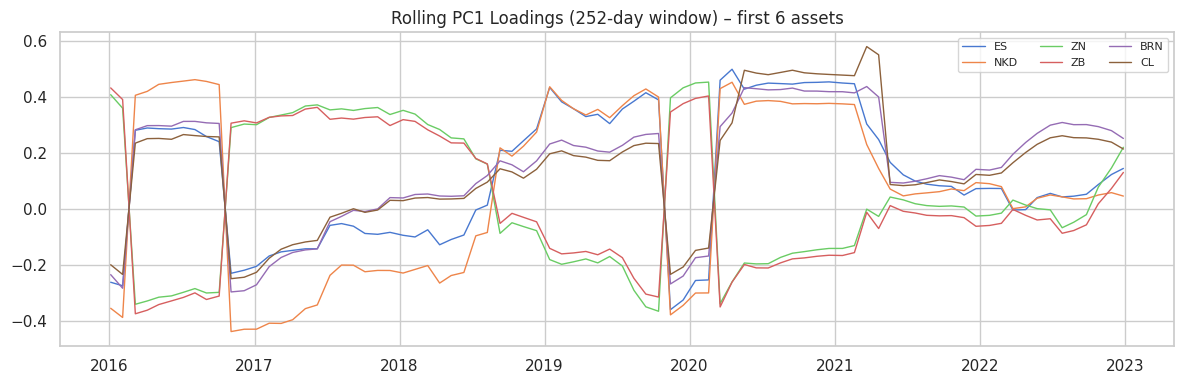

Relatively stable loadings confirm the PC1 structure is not an artefact of a single regime.


In [14]:
# ── Rolling PCA stability (PC1 loadings) ─────────────────────────────────
ROLL = 252
pc1_roll, dates_roll = [], []
A_np = scaler_pca.transform(A_train)
for start in range(0, len(A_np) - ROLL, 21):
    end = start + ROLL
    pca_r = PCA(n_components=1); pca_r.fit(A_np[start:end])
    pc1_roll.append(pca_r.components_[0])
    dates_roll.append(A_train.index[end])

load_roll = pd.DataFrame(pc1_roll, index=dates_roll, columns=A.columns)
fig, ax = plt.subplots(figsize=(12, 4))
for col in A.columns[:6]:
    ax.plot(load_roll.index, load_roll[col], label=col, linewidth=1)
ax.set_title("Rolling PC1 Loadings (252-day window) – first 6 assets", fontsize=12)
ax.legend(ncol=3, fontsize=8); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()
print("Relatively stable loadings confirm the PC1 structure is not an artefact of a single regime.")


## 6. Trend-Following Portfolio (Bonus)

Inspired by **Moskowitz, Ooi & Pedersen (2012)** *Time Series Momentum*.

**Signal**: 12-month (252-day) rolling return normalised by 63-day EWMA volatility (vol-scaled TSMOM).  
**Position sizing**: proportional to signal / EWM-vol, portfolio rescaled to 10% annualised target vol.  
**Execution lag**: 1 day to prevent look-ahead bias.


In [15]:
LOOKBACK = 252; VOL_WINDOW = 63; PORT_VOL = 0.10

A_full   = assets.fillna(0)
past_ret = A_full.rolling(LOOKBACK).sum().shift(1)
ewm_vol_a = A_full.ewm(span=VOL_WINDOW, min_periods=30).std()
signal    = (past_ret / (ewm_vol_a * np.sqrt(LOOKBACK))).fillna(0)

pos_raw   = (np.sign(signal) / ewm_vol_a.replace(0, np.nan)).fillna(0)
raw_ret   = (pos_raw * A_full).sum(axis=1)
pvol      = raw_ret.ewm(span=63, min_periods=30).std() * ANNUALIZE
scale     = (PORT_VOL / pvol).replace([np.inf,-np.inf], np.nan).fillna(PORT_VOL)
weights_ts = pos_raw.multiply(scale, axis=0)

trend_returns = (weights_ts.shift(1) * A_full).sum(axis=1)
trend_returns = trend_returns.loc[trend_returns.index >= A_full.index[LOOKBACK]]

ew_ret = A_full.mean(axis=1).loc[trend_returns.index]

def perf_metrics(ret, label=""):
    ann_ret = ret.mean() * 252; ann_vol = ret.std() * ANNUALIZE
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + ret).cumprod(); mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {"Ann. Return": round(ann_ret,4), "Ann. Vol": round(ann_vol,4),
            "Sharpe": round(sharpe,3), "Max DD": round(mdd,4),
            "Calmar": round(ann_ret / abs(mdd),3) if mdd != 0 else np.nan}

print(pd.DataFrame([perf_metrics(trend_returns), perf_metrics(ew_ret)],
                   index=["TSMOM","EW Benchmark"]).to_string())


              Ann. Return  Ann. Vol  Sharpe  Max DD  Calmar
TSMOM              0.0443    0.1123   0.394 -0.2663   0.166
EW Benchmark       0.0387    0.0983   0.394 -0.2608   0.148


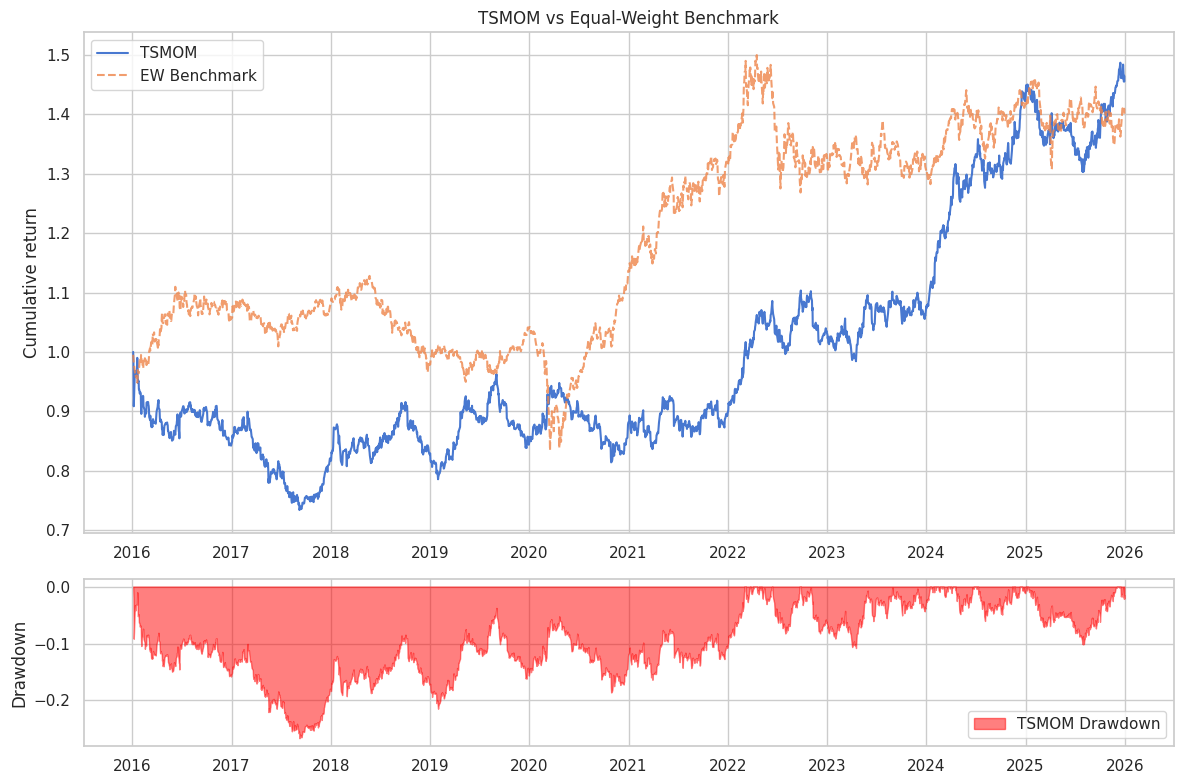

In [16]:
# ── Cumulative returns & drawdown ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3,1]})
cum_trend = (1 + trend_returns).cumprod(); cum_ew = (1 + ew_ret).cumprod()
axes[0].plot(cum_trend, label="TSMOM", linewidth=1.5)
axes[0].plot(cum_ew, label="EW Benchmark", linewidth=1.5, linestyle="--", alpha=0.8)
axes[0].set_ylabel("Cumulative return"); axes[0].legend()
axes[0].set_title("TSMOM vs Equal-Weight Benchmark")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

dd = (cum_trend - cum_trend.cummax()) / cum_trend.cummax()
axes[1].fill_between(dd.index, dd.values, 0, alpha=0.5, color="red", label="TSMOM Drawdown")
axes[1].set_ylabel("Drawdown"); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()


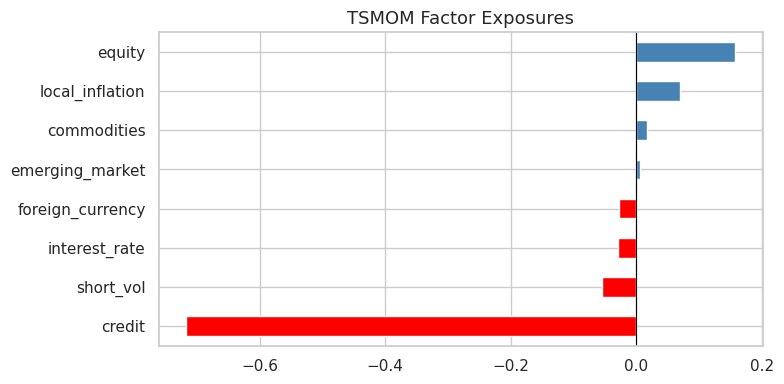

equity              0.1577
interest_rate      -0.0297
commodities         0.0161
credit             -0.7171
emerging_market     0.0064
local_inflation     0.0688
foreign_currency   -0.0270
short_vol          -0.0552

• Low equity beta → diversifying vs passive equity allocations (classic CTA profile)
• Positive short_vol and commodity exposure → trend profits during vol/commodity momentum
• Positive interest_rate beta → benefits from sustained rate moves (2022 regime)
• Negative credit beta → trend naturally short credit during stress periods



In [17]:
# ── Factor exposure of TSMOM ─────────────────────────────────────────────
tr_clean   = trend_returns.dropna()
F_tr       = factors.loc[tr_clean.index]
vol_tr     = F_tr.std(axis=1).ewm(span=60, min_periods=20).mean().bfill()
wls_tr     = 1.0 / vol_tr.clip(lower=vol_tr.quantile(0.05))
wls_tr     = (wls_tr / wls_tr.mean()).values

scaler_tr  = StandardScaler(); Xts = scaler_tr.fit_transform(F_tr.values)
ridge_tr   = RidgeCV(alphas=alphas_grid, fit_intercept=True, cv=5)
ridge_tr.fit(Xts, tr_clean.values, sample_weight=wls_tr)
beta_trend = ridge_tr.coef_ / scaler_tr.scale_
beta_df    = pd.Series(dict(zip(factors.columns, beta_trend)), name="TSMOM β")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["red" if v < 0 else "steelblue" for v in beta_df.sort_values()]
beta_df.sort_values().plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("TSMOM Factor Exposures", fontsize=13)
plt.tight_layout(); plt.show()
print(beta_df.round(4).to_string())
print("""
• Low equity beta → diversifying vs passive equity allocations (classic CTA profile)
• Positive short_vol and commodity exposure → trend profits during vol/commodity momentum
• Positive interest_rate beta → benefits from sustained rate moves (2022 regime)
• Negative credit beta → trend naturally short credit during stress periods
""")


## 7. Reusable Pipeline

Column-agnostic implementation: works on any folder containing `factors.csv`, `assets.csv`, `portfolios.csv` with arbitrary column names.


In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# ── Utilities ─────────────────────────────────────────────────────────────
def read_returns(path):
    return pd.read_csv(path, index_col=0, parse_dates=True)

def load_dataset(data_path):
    data_path = Path(data_path)
    return {
        "factors":    read_returns(data_path / "factors.csv"),
        "assets":     read_returns(data_path / "assets.csv"),
        "portfolios": read_returns(data_path / "portfolios.csv"),
    }

def _wls_weights(df, span=60, min_periods=20, clip_q=0.05):
    """Inverse-EWMA-variance weights; bfill warm-up NaNs."""
    vol = df.std(axis=1).ewm(span=span, min_periods=min_periods).mean().bfill()
    w   = 1.0 / vol.clip(lower=vol.quantile(clip_q))
    return (w / w.mean()).values

def _ridge_wls(X, y, weights, alphas=np.logspace(-4, 2, 50)):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    ridge = RidgeCV(alphas=alphas, fit_intercept=True, cv=5)
    ridge.fit(Xs, y, sample_weight=weights)
    beta  = ridge.coef_ / scaler.scale_
    alpha = ridge.intercept_ - (scaler.mean_ / scaler.scale_ * ridge.coef_).sum()
    return float(alpha), beta, float(ridge.alpha_)

def _r2(y, yhat):
    ss_t = np.sum((y - y.mean())**2)
    return float(1 - np.sum((y - yhat)**2) / ss_t) if ss_t > 0 else np.nan

def _perf_metrics(ret):
    ANNUALIZE = np.sqrt(252)
    ann_ret   = float(ret.mean() * 252)
    ann_vol   = float(ret.std()  * ANNUALIZE)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum       = (1 + ret).cumprod()
    mdd       = float(((cum - cum.cummax()) / cum.cummax()).min())
    return {"ann_return": ann_ret, "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": mdd}

# ── Main pipeline ─────────────────────────────────────────────────────────
def run_pipeline(data_path):
    """
    Full factor analysis pipeline.

    Parameters
    ----------
    data_path : str | Path
        Directory containing factors.csv, assets.csv, portfolios.csv.

    Returns
    -------
    dict with keys:
        exposures   – Ridge-WLS factor loadings per portfolio
        performance – annualised metrics + in-sample R² per portfolio
        pca         – PCA components, loadings, factor returns, portfolio R²
        trend       – TSMOM returns, weights, performance, factor exposures
    """
    ANNUALIZE   = np.sqrt(252)
    PORT_VOL    = 0.10       # trend target vol
    LOOKBACK    = 252        # TSMOM lookback
    PCA_VAR_THR = 0.80       # PCA variance threshold
    SPLIT       = "2023-01-01"  # train/test split for PCA
    ALPHAS      = np.logspace(-4, 2, 50)

    # Load & preprocess
    ds          = load_dataset(data_path)
    factors_    = ds["factors"]
    assets_     = ds["assets"].fillna(ds["assets"].median())
    portfolios_ = ds["portfolios"].replace(0, np.nan).ffill().fillna(0)

    # ── 1. Factor exposures (Ridge-WLS) ─────────────────────────────────
    idx    = factors_.index.intersection(portfolios_.index)
    F_np   = factors_.loc[idx].values
    P_aln  = portfolios_.loc[idx]
    f_cols = factors_.columns.tolist()
    wls_w  = _wls_weights(factors_.loc[idx])

    exposures = {}
    for port in P_aln.columns:
        y            = P_aln[port].values
        a, beta, ra  = _ridge_wls(F_np, y, wls_w, ALPHAS)
        yhat         = F_np @ beta + a
        exposures[port] = {
            "alpha":       a,
            "betas":       dict(zip(f_cols, beta.tolist())),
            "r2":          _r2(y, yhat),
            "ridge_alpha": ra,
        }

    # ── 2. Performance per portfolio ─────────────────────────────────────
    performance = {}
    for port in P_aln.columns:
        m = _perf_metrics(P_aln[port])
        m["r2_factor_model"] = exposures[port]["r2"]
        performance[port] = m

    # ── 3. PCA on assets ────────────────────────────────────────────────
    idx_a   = factors_.index.intersection(assets_.index)
    A       = assets_.loc[idx_a]
    A_tr    = A.loc[:SPLIT] if SPLIT in A.index or A.index.min() < pd.Timestamp(SPLIT) else A
    sc_pca  = StandardScaler()
    A_tr_s  = sc_pca.fit_transform(A_tr)
    A_all_s = sc_pca.transform(A)

    pca_full = PCA(); pca_full.fit(A_tr_s)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
    k        = int(np.searchsorted(cumvar, PCA_VAR_THR)) + 1
    pca_m    = PCA(n_components=k); pca_m.fit(A_tr_s)
    pc_cols  = [f"PC{i+1}" for i in range(k)]
    pca_df_  = pd.DataFrame(pca_m.transform(A_all_s), index=A.index, columns=pc_cols)

    idx_pc  = pca_df_.index.intersection(P_aln.index)
    X_pc    = pca_df_.loc[idx_pc].values
    P_pc    = P_aln.loc[idx_pc]
    wls_pc  = pd.Series(wls_w, index=idx).loc[idx_pc].values

    pca_exposures = {}
    for port in P_pc.columns:
        y           = P_pc[port].values
        a, beta, ra = _ridge_wls(X_pc, y, wls_pc, ALPHAS)
        yhat        = X_pc @ beta + a
        pca_exposures[port] = {
            "alpha": a,
            "betas": dict(zip(pc_cols, beta.tolist())),
            "r2":    _r2(y, yhat),
        }

    pca_out = {
        "n_components":       k,
        "explained_variance": pca_m.explained_variance_ratio_.tolist(),
        "loadings":           pd.DataFrame(pca_m.components_.T,
                                           index=A.columns, columns=pc_cols),
        "pca_factor_returns": pca_df_,
        "pca_exposures":      pca_exposures,
    }

    # ── 4. Trend-following portfolio (TSMOM) ─────────────────────────────
    A_t      = ds["assets"].fillna(0)
    past_r   = A_t.rolling(LOOKBACK).sum().shift(1)
    evol_a   = A_t.ewm(span=63, min_periods=30).std()
    signal   = (past_r / (evol_a * np.sqrt(LOOKBACK))).fillna(0)
    pos_raw  = (np.sign(signal) / evol_a.replace(0, np.nan)).fillna(0)
    raw_r    = (pos_raw * A_t).sum(axis=1)
    pvol     = raw_r.ewm(span=63, min_periods=30).std() * ANNUALIZE
    scale    = (PORT_VOL / pvol).replace([np.inf,-np.inf], np.nan).fillna(PORT_VOL)
    wt_fin   = pos_raw.multiply(scale, axis=0)
    tr       = (wt_fin.shift(1) * A_t).sum(axis=1)
    tr       = tr.loc[tr.index >= A_t.index[LOOKBACK]]

    tr_clean = tr.dropna()
    F_tr     = factors_.loc[tr_clean.index]
    wls_tr   = _wls_weights(F_tr)
    a_tr, beta_tr, _ = _ridge_wls(F_tr.values, tr_clean.values, wls_tr, ALPHAS)

    trend_out = {
        "returns":          tr,
        "weights":          wt_fin.loc[tr.index],
        "performance":      _perf_metrics(tr_clean),
        "factor_exposures": dict(zip(f_cols, beta_tr.tolist())),
        "alpha":            a_tr,
    }

    return {
        "exposures":   exposures,
        "performance": performance,
        "pca":         pca_out,
        "trend":       trend_out,
    }

# ── Smoke test ────────────────────────────────────────────────────────────
results = run_pipeline(DATA_DIR)
print("=== run_pipeline smoke-test ===")
print("Keys:", list(results.keys()))
print("\nPortfolio Sharpe ratios:")
for p, m in results["performance"].items():
    print(f"  {p:<35} Sharpe={m['sharpe']:.3f}  R²={m['r2_factor_model']:.3f}")
print(f"\nPCA n_components selected: {results['pca']['n_components']}")
print(f"Trend Sharpe:  {results['trend']['performance']['sharpe']:.3f}")
print(f"Trend Max DD:  {results['trend']['performance']['max_drawdown']:.3f}")
print("\n✓ Pipeline ran successfully end-to-end.")


=== run_pipeline smoke-test ===
Keys: ['exposures', 'performance', 'pca', 'trend']

Portfolio Sharpe ratios:
  portfolio_equal_weight              Sharpe=0.195  R²=0.834
  portfolio_inverse_vol               Sharpe=-0.433  R²=0.620
  portfolio_trend                     Sharpe=0.510  R²=0.151
  portfolio_trend_neutral             Sharpe=0.086  R²=0.124

PCA n_components selected: 10
Trend Sharpe:  0.394
Trend Max DD:  -0.266

✓ Pipeline ran successfully end-to-end.
